# O que explica o preço de um apartamento em São Paulo?
## Uma análise de regressão linear e polinomial

**Data Science & Statistical Computing — Checkpoint 4 — FIAP 2026**

**Grupo:** Enzo Augusto (RM562249) · Rafaell Santiago (RM564386) · Gustavo Neres (RM561785) · Sebastian Iriarte (RM563619)

---

## 1. Proposição do problema

Comprar um imóvel é uma das maiores decisões financeiras de uma família. O preço de um
apartamento depende de vários fatores: o tamanho, quantos quartos tem, quantas vagas de
garagem e, principalmente, o bairro em que fica.

Neste projeto queremos entender **quais características ajudam a explicar o preço de venda
de um apartamento na cidade de São Paulo** e construir um modelo capaz de estimar esse preço.

### Pergunta de pesquisa

> Em que medida a área, o número de quartos, o número de banheiros, as vagas de garagem e
> o distrito ajudam a explicar o preço de venda de um apartamento em São Paulo?

### Variável resposta (y)

- **preco** — preço de venda do apartamento, em **reais (R$)**. É uma variável numérica
  contínua: é o valor que queremos explicar.

### Variáveis explicativas (X)

| Variável | Unidade | O que é |
|---|---|---|
| `area_m2` | m² | Área útil do apartamento |
| `quartos` | contagem | Número de quartos |
| `banheiros` | contagem | Número de banheiros |
| `vagas` | contagem | Vagas de garagem |
| `distrito` | categoria | Distrito de São Paulo onde fica o imóvel |

### Unidade de observação

Cada linha da base é **um apartamento anunciado à venda**.

### Relevância

Entender o que forma o preço ajuda compradores a avaliar se um anúncio está caro ou barato,
e ajuda vendedores a definir um preço compatível com o mercado.

### Hipóteses iniciais (registradas antes de modelar)

- **H1** — Quanto maior a área, maior o preço.
- **H2** — O distrito influencia bastante o preço (bairros nobres custam mais).
- **H3** — Mais vagas de garagem estão associadas a preços maiores.
- **H4** — A relação entre área e preço pode ser **não linear**: em imóveis de alto padrão,
  cada m² adicional tende a valer mais. Vamos verificar isso nos gráficos.

> **Observação importante:** associação não é causalidade. Este é um estudo observacional —
> identificamos relações estatísticas, não relações de causa e efeito.

## 2. Origem e documentação dos dados

- **Base:** *São Paulo Real Estate — Sale/Rent — April 2019*
- **Fonte:** conjunto público disponibilizado no Kaggle, compilado a partir de anúncios de
  imóveis da cidade de São Paulo.
- **Endereço:** https://www.kaggle.com/datasets/argonalyst/sao-paulo-real-estate-sale-rent-april-2019
- **Data de acesso:** agosto de 2026.
- **Período de referência:** abril de 2019.
- **Dimensão original:** 13.640 anúncios e 16 colunas (venda e aluguel).
- **Unidade de observação:** cada linha é um anúncio de imóvel.
- **Condições de uso:** base pública, disponibilizada para fins educacionais.

> **Limitação da fonte:** os dados vêm de **anúncios**, ou seja, refletem o preço **pedido**
> pelo vendedor, que pode diferir do preço final de venda. Isso será retomado nas limitações.

### Dicionário de dados (variáveis utilizadas)

| Variável | Tipo | Unidade / categorias | Descrição |
|---|---|---|---|
| `preco` | Numérica contínua | R$ | **Resposta.** Preço de venda anunciado. |
| `area_m2` | Numérica contínua | m² | Área útil do imóvel. |
| `quartos` | Numérica discreta | contagem | Número de quartos. |
| `banheiros` | Numérica discreta | contagem | Número de banheiros. |
| `vagas` | Numérica discreta | contagem | Vagas de garagem. |
| `distrito` | Categórica nominal | 96 distritos | Distrito de São Paulo. |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Lemos a base direto da internet, o que torna a análise reproduzível
url = "https://raw.githubusercontent.com/mathdeoliveira/files/master/sao-paulo-properties-april-2019.csv"
imoveis = pd.read_csv(url)

print("Dimensões da base original:", imoveis.shape)
imoveis.head()

Dimensões da base original: (13640, 16)


,Price,Condo,Size,Rooms,Toilets,Suites,Parking,Elevator,Furnished,Swimming Pool,New,District,Negotiation Type,Property Type,Latitude,Longitude
0,930,220,47,2,2,1,1,0,0,0,0,Artur Alvim/São Paulo,rent,apartment,-23.543138,-46.479486
1,1000,148,45,2,2,1,1,0,0,0,0,Artur Alvim/São Paulo,rent,apartment,-23.550239,-46.480718
2,1000,100,48,2,2,1,1,0,0,0,0,Artur Alvim/São Paulo,rent,apartment,-23.542818,-46.485665
3,1000,200,48,2,2,1,1,0,0,0,0,Artur Alvim/São Paulo,rent,apartment,-23.547171,-46.483014
4,1300,410,55,2,2,1,1,1,0,0,0,Artur Alvim/São Paulo,rent,apartment,-23.525025,-46.482436


## 3. Data wrangling (preparação dos dados)

Para cada problema encontrado registramos **o que foi encontrado**, **a decisão tomada** e
**quantas observações foram afetadas**.

In [2]:
# A base contém imóveis à venda e para alugar. Nosso tema é VENDA.
print(imoveis["Negotiation Type"].value_counts())

venda = imoveis[imoveis["Negotiation Type"] == "sale"].copy()
print("\nApenas imóveis à venda:", venda.shape)

Negotiation Type
rent    7228
sale    6412
Name: count, dtype: int64

Apenas imóveis à venda: (6412, 16)


In [3]:
# Renomeamos as colunas para português e selecionamos as que vamos usar
venda = venda.rename(columns={
    "Price": "preco",
    "Size": "area_m2",
    "Rooms": "quartos",
    "Toilets": "banheiros",
    "Parking": "vagas",
    "District": "distrito",
    "Condo": "condominio",
})

# O distrito vem escrito como "Moema/São Paulo". Ficamos apenas com o nome do bairro.
venda["distrito"] = venda["distrito"].str.replace("/São Paulo", "", regex=False)

df = venda[["preco", "area_m2", "quartos", "banheiros", "vagas", "distrito", "condominio"]].copy()
print("Base de trabalho:", df.shape)
df.head()

Base de trabalho: (6412, 7)


,preco,area_m2,quartos,banheiros,vagas,distrito,condominio
4901,732600,74,1,2,2,Vila Madalena,1000
4902,1990000,164,4,5,3,Vila Madalena,2400
4903,720000,70,2,2,1,Vila Madalena,700
4904,1680000,155,3,5,2,Vila Madalena,1580
4905,1200000,56,2,2,2,Vila Madalena,900


In [4]:
# Diagnóstico inicial
print("Valores ausentes por coluna:")
print(df.isna().sum())

print("\nLinhas duplicadas:", df.duplicated().sum())

print("\nTipos de dados:")
print(df.dtypes)

Valores ausentes por coluna:
preco         0
area_m2       0
quartos       0
banheiros     0
vagas         0
distrito      0
condominio    0
dtype: int64

Linhas duplicadas: 215

Tipos de dados:
preco          int64
area_m2        int64
quartos        int64
banheiros      int64
vagas          int64
distrito      object
condominio     int64
dtype: object


**Duplicatas.** Encontramos **215 linhas** totalmente idênticas. Como todas as colunas
coincidem (preço, área, quartos, banheiros, vagas e distrito), trata-se do **mesmo imóvel
anunciado mais de uma vez** — situação comum em portais de classificados. Decisão: remover.

In [5]:
antes = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f"Removidas {antes - len(df)} linhas duplicadas.")
print("Base após remoção:", df.shape)

Removidas 215 linhas duplicadas.
Base após remoção: (6197, 7)


**Valores impossíveis disfarçados de zero.** A coluna `condominio` tem muitos valores
iguais a **0**. Um condomínio de R$ 0,00 não existe na prática: esses zeros representam
"informação não preenchida" no anúncio. Vamos verificar quantos são.

In [6]:
print("Condomínio igual a zero:", (df["condominio"] == 0).sum(), "de", len(df), "imóveis")
print("Percentual:", round((df["condominio"] == 0).mean() * 100, 1), "%")

Condomínio igual a zero: 1247 de 6197 imóveis
Percentual: 20.1 %


**Decisão sobre o condomínio.** Cerca de **20%** dos imóveis (1.247 de 6.197) não têm essa informação.
Preencher esses valores exigiria uma suposição forte, e o valor do condomínio é mais uma
**consequência** do padrão do imóvel do que uma característica dele.

Por isso **não usaremos o condomínio no modelo** — mas registramos o problema, que é um bom
exemplo de valor ausente escondido como zero.

In [7]:
# Removemos a coluna do condomínio do estudo
df = df.drop(columns=["condominio"])

# Conferindo se há valores impossíveis nas variáveis que vamos usar
print("Preço menor ou igual a zero:", (df["preco"] <= 0).sum())
print("Área menor ou igual a zero:", (df["area_m2"] <= 0).sum())
print("\nFaixa de preço: R$", df["preco"].min(), "a R$", df["preco"].max())
print("Faixa de área:", df["area_m2"].min(), "a", df["area_m2"].max(), "m²")

Preço menor ou igual a zero: 0
Área menor ou igual a zero: 0

Faixa de preço: R$ 42000 a R$ 10000000
Faixa de área: 30 a 620 m²


**Observações discrepantes (outliers).** Há apartamentos de até R$ 10 milhões na base.
Antes de decidir qualquer coisa, precisamos **investigar** se são erros de digitação ou
imóveis reais.

In [8]:
# Investigando os imóveis mais caros
df.nlargest(8, "preco")[["preco", "area_m2", "quartos", "vagas", "distrito"]]

,preco,area_m2,quartos,vagas,distrito
1080,10000000,343,4,5,Iguatemi
1085,9979947,343,4,5,Iguatemi
2004,8500000,420,4,4,Jardim Paulista
106,8039200,278,4,4,Vila Olimpia
104,8000000,278,4,5,Vila Olimpia
1907,8000000,269,4,4,Itaim Bibi
1084,7765616,279,4,4,Iguatemi
2370,7559420,377,3,4,Alto de Pinheiros


**Interpretação e decisão.** Os imóveis mais caros ficam em **Iguatemi, Jardim Paulista,
Vila Olímpia, Itaim Bibi e Alto de Pinheiros** — distritos reconhecidamente de alto padrão em
São Paulo. Todos têm áreas grandes (270 a 420 m²), 4 quartos e 4 a 5 vagas.

Ou seja: **não são erros**, são apartamentos de luxo reais. Como fazem parte do mercado
imobiliário paulistano, decidimos **mantê-los**. Removê-los seria descartar uma parte
legítima do fenômeno que queremos estudar.

### Resumo dos tratamentos

| Problema encontrado | Investigação realizada | Decisão | Linhas afetadas |
|---|---|---|---|
| Base mistura venda e aluguel | Conferimos a coluna `Negotiation Type` | Manter apenas os imóveis à venda | 7.228 removidas |
| Colunas em inglês | — | Renomeadas para português | — (transformação) |
| Distrito com sufixo "/São Paulo" | — | Texto padronizado, mantendo só o bairro | todas (transformação) |
| 215 linhas idênticas | Todas as colunas coincidem | Removidas (mesmo anúncio repetido) | 215 |
| Condomínio igual a zero | 1.247 imóveis (≈20%) sem a informação | Variável excluída do modelo | — |
| Preços muito altos | Verificamos que são imóveis de luxo em bairros nobres reais | **Mantidos** (fazem parte do mercado) | 0 |

**Dimensões:** a base saiu de **13.640 × 16** (original) para **6.197 × 6** (tratada).

In [9]:
print("Base original:", imoveis.shape)
print("Base tratada :", df.shape)
print("\nValores ausentes restantes:", df.isna().sum().sum())
df.head()

Base original: (13640, 16)
Base tratada : (6197, 6)

Valores ausentes restantes: 0


,preco,area_m2,quartos,banheiros,vagas,distrito
0,732600,74,1,2,2,Vila Madalena
1,1990000,164,4,5,3,Vila Madalena
2,720000,70,2,2,1,Vila Madalena
3,1680000,155,3,5,2,Vila Madalena
4,1200000,56,2,2,2,Vila Madalena


## 4. Análise exploratória

Cada gráfico responde a uma pergunta da análise e vem seguido de sua interpretação.

In [10]:
# Estatísticas descritivas da variável resposta
df["preco"].describe().round(0)

,preco
count,6197.0
mean,616425.0
std,744222.0
min,42000.0
25%,250000.0
50%,385000.0
75%,683400.0
max,10000000.0


**Interpretação.** O preço médio é de aproximadamente **R$ 616 mil**, enquanto a mediana
é de **R$ 385 mil**. Como a média é bem **maior** que a mediana, a distribuição é
**assimétrica à direita**: existem apartamentos de altíssimo valor que puxam a média para
cima, enquanto a maioria se concentra em valores mais baixos.

Metade dos apartamentos custa entre R$ 250 mil e R$ 683 mil (1º e 3º quartis).

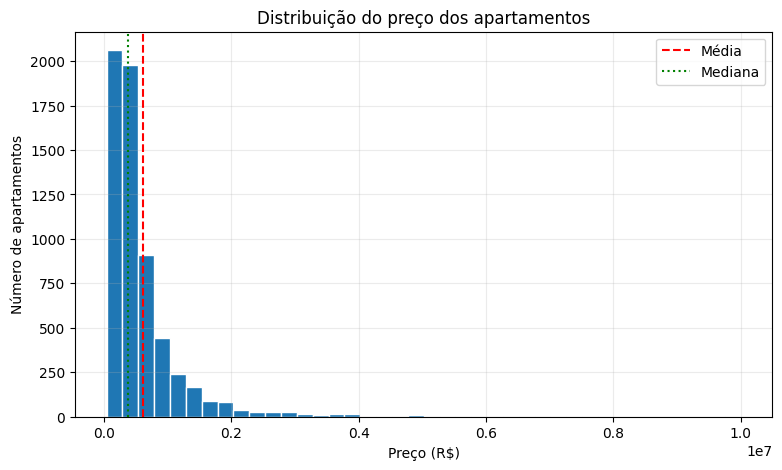

In [11]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(df["preco"], bins=40, edgecolor="white")
ax.axvline(df["preco"].mean(), color="red", linestyle="--", label="Média")
ax.axvline(df["preco"].median(), color="green", linestyle=":", label="Mediana")
ax.set_title("Distribuição do preço dos apartamentos")
ax.set_xlabel("Preço (R$)")
ax.set_ylabel("Número de apartamentos")
ax.legend()
ax.grid(alpha=0.25)
plt.show()

**Interpretação.** O gráfico confirma a assimetria: a grande maioria dos apartamentos
está concentrada abaixo de R$ 1 milhão, com uma **cauda longa à direita** formada pelos
imóveis de alto padrão. A linha vermelha (média) fica à direita da verde (mediana),
exatamente por causa desses valores extremos.

In [12]:
# Verificando se restaram valores ausentes
print("Valores ausentes na base tratada:")
print(df.isna().sum())

Valores ausentes na base tratada:
preco        0
area_m2      0
quartos      0
banheiros    0
vagas        0
distrito     0
dtype: int64


**Interpretação.** Não há valores ausentes na base tratada. O único problema desse tipo
era o condomínio preenchido com zero, que resolvemos excluindo a variável do estudo.

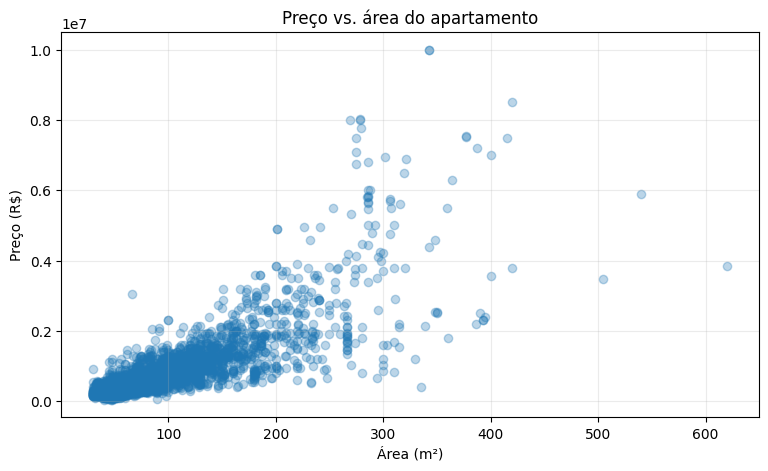

In [13]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(df["area_m2"], df["preco"], alpha=0.3)
ax.set_title("Preço vs. área do apartamento")
ax.set_xlabel("Área (m²)")
ax.set_ylabel("Preço (R$)")
ax.grid(alpha=0.25)
plt.show()

**Interpretação.** A relação é claramente **positiva**: apartamentos maiores custam mais,
confirmando a **H1**. Além disso, os pontos **não formam uma reta perfeita** — nos imóveis
maiores a nuvem se abre e sobe de forma mais acentuada, sugerindo que o preço cresce em ritmo
crescente. Essa possível **curvatura** justifica testarmos um modelo polinomial (**H4**).

A dispersão também aumenta com a área: apartamentos de mesmo tamanho podem ter preços bem
diferentes, sinal de que outros fatores (como o distrito) pesam bastante.

area_m2      0.82
vagas        0.70
banheiros    0.64
quartos      0.49
Name: preco, dtype: float64


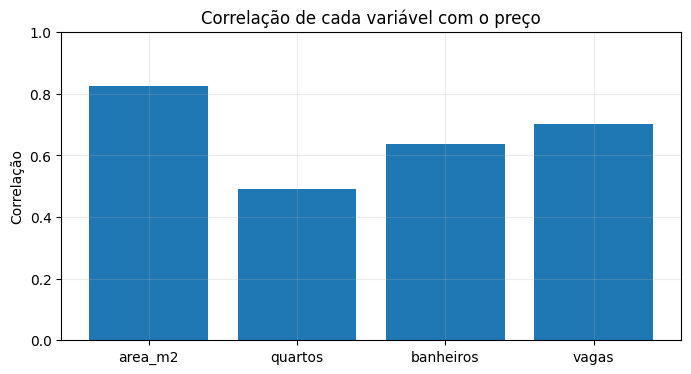

In [14]:
# Correlação de cada variável com o preço
num = ["area_m2", "quartos", "banheiros", "vagas"]
correlacoes = df[["preco"] + num].corr()["preco"].drop("preco")

print(correlacoes.sort_values(ascending=False).round(2))

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(correlacoes.index, correlacoes.values)
ax.set_title("Correlação de cada variável com o preço")
ax.set_ylabel("Correlação")
ax.set_ylim(0, 1)
ax.grid(alpha=0.25)
plt.show()

**Interpretação.** A **correlação** mede, de −1 a +1, o quanto duas variáveis andam
juntas. Todas as variáveis têm correlação **positiva** com o preço:

- **área** (≈ 0,82) — de longe a mais forte;
- **vagas** (≈ 0,70) e **banheiros** (≈ 0,64) — também relevantes;
- **quartos** (≈ 0,49) — a mais fraca das quatro.

É interessante notar que o número de quartos importa menos que a área: um apartamento de
80 m² com 2 quartos pode valer mais que um de 60 m² com 3 quartos.

> Atenção: a correlação mede apenas relação **linear**. Ela não captura bem curvaturas, por
> isso analisamos o gráfico **e** o número em conjunto.

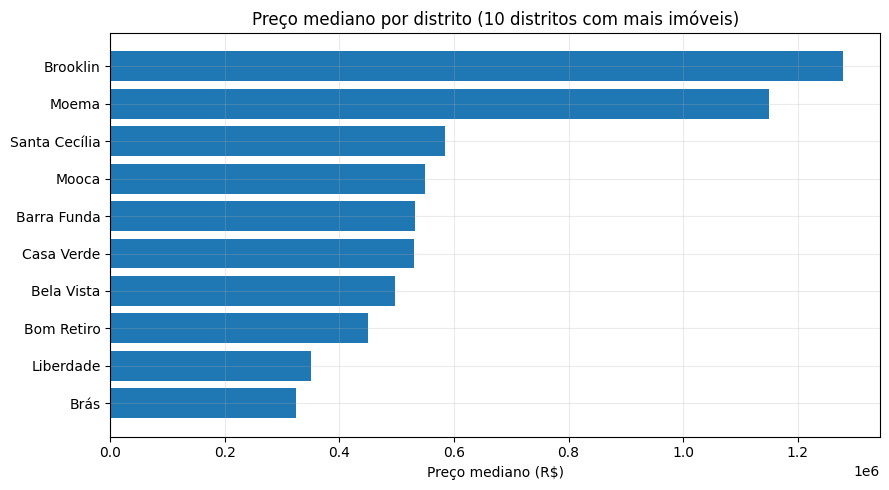

distrito
Brás              324500.0
Liberdade         350000.0
Bom Retiro        450000.0
Bela Vista        497500.0
Casa Verde        530000.0
Barra Funda       531900.0
Mooca             550000.0
Santa Cecília     583950.0
Moema            1150000.0
Brooklin         1280000.0
Name: preco, dtype: float64


In [15]:
# Preço mediano por distrito (10 distritos com mais imóveis)
top10 = df["distrito"].value_counts().head(10).index
resumo = df[df["distrito"].isin(top10)].groupby("distrito")["preco"].median().sort_values()

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(resumo.index, resumo.values)
ax.set_title("Preço mediano por distrito (10 distritos com mais imóveis)")
ax.set_xlabel("Preço mediano (R$)")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

print(resumo.round(0))

**Interpretação.** O preço mediano varia muito entre distritos, confirmando a **H2**.
Entre os dez distritos com mais imóveis, o mais barato é o **Brás** (mediana de cerca de
R$ 324 mil) e o mais caro é o **Brooklin** (mediana de Rs 1,28 milhão) — quase **4 vezes**
de diferença. Considerando toda a base, a diferença entre o distrito mais barato e o mais
caro passa de **10 vezes**.

Ou seja, dois apartamentos com a mesma área e o mesmo número de quartos podem ter preços
completamente diferentes dependendo da localização. Por isso o distrito precisa entrar no
modelo.

**Limitação identificada:** alguns distritos têm poucos imóveis na base, o que torna suas
estimativas menos confiáveis.

## 5. Preparação para a modelagem

**Variáveis utilizadas.** `area_m2`, `quartos`, `banheiros`, `vagas` e `distrito` para
explicar `preco`.

**Exclusões justificadas.** O `condominio` foi excluído por ter ~20% de valores ausentes
disfarçados de zero. As colunas de latitude, longitude, tipo de imóvel e tipo de negociação
também não entram: as duas primeiras já são representadas pelo distrito, e as duas últimas
são constantes após o filtro (todos são apartamentos à venda).

**Variável categórica.** O distrito será transformado em colunas 0/1 (uma para cada
distrito), pois o modelo só trabalha com números.

**Divisão treino/teste.** Separamos 70% dos dados para treinar o modelo e 30% para testá-lo.
O conjunto de teste simula imóveis que o modelo nunca viu — é nele que medimos o erro real.
Fazemos essa separação **antes** de qualquer transformação, para evitar **vazamento de
dados** (quando informação do teste influencia o treino e a avaliação fica otimista demais).

In [16]:
from sklearn.model_selection import train_test_split

y = df["preco"]                                                    # o que queremos prever
X = df[["area_m2", "quartos", "banheiros", "vagas", "distrito"]]   # as características

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,      # 30% para teste
    random_state=42      # fixa o sorteio, para o resultado ser sempre o mesmo
)

print("Treino:", X_train.shape)
print("Teste :", X_test.shape)

Treino: (4337, 5)
Teste : (1860, 5)


## 6. Modelagem

Construímos quatro modelos, do mais simples ao mais completo:

1. **Modelo de referência** — prevê sempre a média dos preços. Serve de "chão": qualquer
   modelo útil precisa errar menos que ele.
2. **Regressão linear simples** — usa apenas a área, a variável mais correlacionada com o preço.
3. **Regressão linear múltipla** — usa todas as variáveis escolhidas.
4. **Regressão polinomial (grau 2)** — acrescenta a área elevada ao quadrado, para testar a
   curvatura observada na análise exploratória.

In [17]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# MODELO 1 — Referência: prevê sempre a média do treino
media_treino = y_train.mean()
prev_referencia = np.full(len(y_test), media_treino)

print("Preço médio do treino: R$", round(media_treino))

Preço médio do treino: R$ 624425


In [18]:
# MODELO 2 — Regressão linear simples: apenas a área
modelo_simples = LinearRegression()
modelo_simples.fit(X_train[["area_m2"]], y_train)

prev_simples = modelo_simples.predict(X_test[["area_m2"]])

print("Coeficiente da área: R$", round(modelo_simples.coef_[0]), "por m²")
print("Intercepto: R$", round(modelo_simples.intercept_))

Coeficiente da área: R$ 11872 por m²
Intercepto: R$ -326527


**Interpretação do modelo simples.** A equação estimada é:

**preço = −326.527 + 11.872 × área**

Ou seja, cada metro quadrado adicional está associado a um aumento de aproximadamente
**R$ 11.872** no preço. O intercepto negativo não tem sentido prático (não existe imóvel de
0 m²); ele serve apenas para posicionar a reta.

In [19]:
# MODELO 3 — Regressão linear múltipla
# Transformamos o distrito em colunas 0/1 ("é desse distrito? 1 = sim, 0 = não")
X_train_d = pd.get_dummies(X_train, columns=["distrito"], drop_first=True)
X_test_d  = pd.get_dummies(X_test,  columns=["distrito"], drop_first=True)

# Garante que treino e teste tenham exatamente as mesmas colunas
X_test_d = X_test_d.reindex(columns=X_train_d.columns, fill_value=0)

print("Número de colunas após a transformação:", X_train_d.shape[1])

modelo_multiplo = LinearRegression()
modelo_multiplo.fit(X_train_d, y_train)

prev_multiplo = modelo_multiplo.predict(X_test_d)

Número de colunas após a transformação: 99


In [20]:
# MODELO 4 — Regressão polinomial: criamos a coluna da área ao quadrado
X_train_p = X_train_d.copy()
X_test_p  = X_test_d.copy()

X_train_p["area_quadrado"] = X_train_p["area_m2"] ** 2
X_test_p["area_quadrado"]  = X_test_p["area_m2"] ** 2

modelo_polinomial = LinearRegression()
modelo_polinomial.fit(X_train_p, y_train)

prev_polinomial = modelo_polinomial.predict(X_test_p)

print("Modelo polinomial treinado com a coluna da área ao quadrado.")

Modelo polinomial treinado com a coluna da área ao quadrado.


**Por que isso é uma regressão polinomial?** Criamos uma coluna nova com a área elevada
ao quadrado e a entregamos ao modelo como se fosse mais uma variável. O termo ao quadrado
cresce em ritmo diferente do termo simples — se a área dobra, a coluna da área dobra, mas a
do quadrado fica quatro vezes maior. É essa diferença de ritmo que permite ao modelo
desenhar uma **curva** em vez de uma reta.

**Por que grau 2 e não 3?** A curvatura observada no gráfico de dispersão é suave. Um grau
maior aumentaria o risco de sobreajuste sem ganho real.

> A regressão polinomial continua sendo uma regressão **linear**: o termo "linear" se refere
> à forma como o modelo combina os coeficientes (uma soma de termos), e não ao formato da
> curva no gráfico.

## 7. Avaliação dos modelos

Avaliamos os quatro modelos no **mesmo conjunto de teste**, usando três métricas:

- **MAE** (erro absoluto médio) — em média, o modelo erra X reais para mais ou para menos.
- **RMSE** (raiz do erro quadrático médio) — parecido com o MAE, mas eleva os erros ao
  quadrado antes de fazer a média, então **erros grandes pesam mais**.
- **R²** — quanto da variação dos preços o modelo consegue explicar, de 0 a 1.

In [21]:
def calcular_metricas(nome, previsoes):
    return {
        "Modelo": nome,
        "MAE (R$)": round(mean_absolute_error(y_test, previsoes)),
        "RMSE (R$)": round(np.sqrt(mean_squared_error(y_test, previsoes))),
        "R2": round(r2_score(y_test, previsoes), 3),
    }

resultados = pd.DataFrame([
    calcular_metricas("1. Referência (média)", prev_referencia),
    calcular_metricas("2. Linear simples (área)", prev_simples),
    calcular_metricas("3. Linear múltipla", prev_multiplo),
    calcular_metricas("4. Polinomial (área ao quadrado)", prev_polinomial),
]).set_index("Modelo")

resultados

,MAE (R$),RMSE (R$),R2
Modelo,,,
1. Referência (média),406550,736138,-0.001
2. Linear simples (área),187338,406068,0.695
3. Linear múltipla,162471,320744,0.810
4. Polinomial (área ao quadrado),155457,306156,0.827


**Interpretação da comparação.**

- O **modelo de referência** erra em média R\$ 406 mil e tem R² igual a zero,
como esperado: ele ignora as características do imóvel.
- A **regressão simples** com a área já explica cerca de 70% da variação — a
área sozinha é bastante informativa.
- A **regressão múltipla** melhora bastante (R² = 0,810), mostrando que
distrito, vagas e banheiros acrescentam informação relevante.
- O **modelo polinomial** apresenta o melhor desempenho: R² de **0,827** e RMSE
de **R\$ 306.156**, contra R\$ 320.744 do modelo múltiplo — uma redução de cerca
de **4,5%** no erro, e o MAE cai de R\$ 162.471 para R\$ 155.457.

**Modelo escolhido: o polinomial.** O ganho é modesto, mas é consistente nas
três métricas e foi observado no **conjunto de teste**, o que indica que não se
trata de sobreajuste. Além disso, a curvatura já havia sido identificada na
análise exploratória, **antes** da modelagem — ou seja, a escolha não foi feita
apenas pelo maior R².

In [22]:
# Interpretação dos coeficientes do modelo múltiplo
coeficientes = pd.Series(modelo_multiplo.coef_, index=X_train_d.columns)

print("Coeficientes das variáveis numéricas (em R$):")
print(coeficientes[["area_m2", "quartos", "banheiros", "vagas"]].round(0))

Coeficientes das variáveis numéricas (em R$):
area_m2        7844.0
quartos      -74337.0
banheiros     63974.0
vagas        237321.0
dtype: float64


**Interpretação de três coeficientes** (mantendo as demais variáveis constantes):

1. **Área (≈ +R\$ 7.844 por m²).** Cada metro quadrado adicional está associado
   a um aumento de cerca de R\$ 7,8 mil no preço. Note que esse valor é **menor**
   que os R\$ 11,9 mil do modelo simples: parte do efeito que antes era
   atribuído à área agora é explicada pelo distrito e pelas outras variáveis.

2. **Vagas (≈ +R\$ 237.321 por vaga).** É o maior efeito individual: cada vaga
   de garagem adicional está associada a cerca de R\$ 237 mil a mais. Faz
   sentido em São Paulo, onde vaga é um item caro e disputado.

3. **Quartos (≈ −R\$ 74.337 por quarto).** O sinal **negativo** chama atenção,
   mas tem explicação: o coeficiente considera as demais variáveis
   **constantes**. Ou seja, para uma **mesma área**, mais quartos significa
   cômodos menores — o que o mercado tende a valorizar menos que um
   apartamento com menos quartos mais espaçosos.

Esse último caso mostra por que a interpretação "mantendo as demais constantes"
é essencial: isoladamente, mais quartos estão associados a preços maiores
(correlação positiva de 0,49), mas o efeito muda quando controlamos pela área.

> **Uma característica importante deste modelo.** Os coeficientes dos
> distritos **somam um valor fixo em reais**, independentemente do tamanho do
> apartamento. Isso significa que a diferença de preço entre dois distritos é
> sempre a mesma quantia, seja num imóvel de 50 m² ou de 500 m². Voltaremos a
> esse ponto nas limitações (seção 9), porque ele tem consequências para o uso
> do modelo.

## 8. Diagnóstico do modelo final

O **resíduo** é a diferença entre o preço real e o preço previsto. Se o modelo estiver bem
ajustado, os resíduos devem se distribuir aleatoriamente em torno de zero.

In [23]:
residuos = y_test.values - prev_polinomial

print("Média dos resíduos: R$", round(residuos.mean()))
print("Desvio-padrão dos resíduos: R$", round(residuos.std()))

Média dos resíduos: R$ 2983
Desvio-padrão dos resíduos: R$ 306142


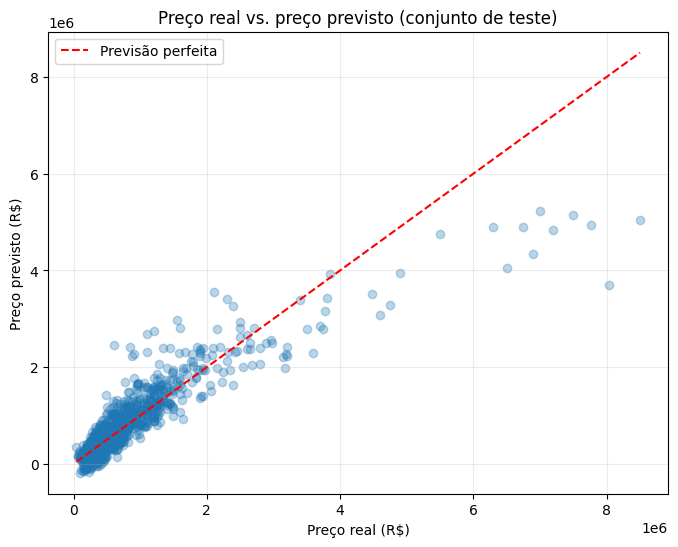

In [24]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(y_test, prev_polinomial, alpha=0.3)
limite = [y_test.min(), y_test.max()]
ax.plot(limite, limite, "r--", label="Previsão perfeita")
ax.set_title("Preço real vs. preço previsto (conjunto de teste)")
ax.set_xlabel("Preço real (R$)")
ax.set_ylabel("Preço previsto (R$)")
ax.legend()
ax.grid(alpha=0.25)
plt.show()

**Interpretação.** A maior parte dos pontos está próxima da linha vermelha (previsão
perfeita), o que indica boas previsões. Nos imóveis mais caros, porém, os pontos se afastam
mais: o modelo tende a **subestimar** apartamentos de altíssimo padrão, pois há poucos
exemplos desse tipo para o modelo aprender.

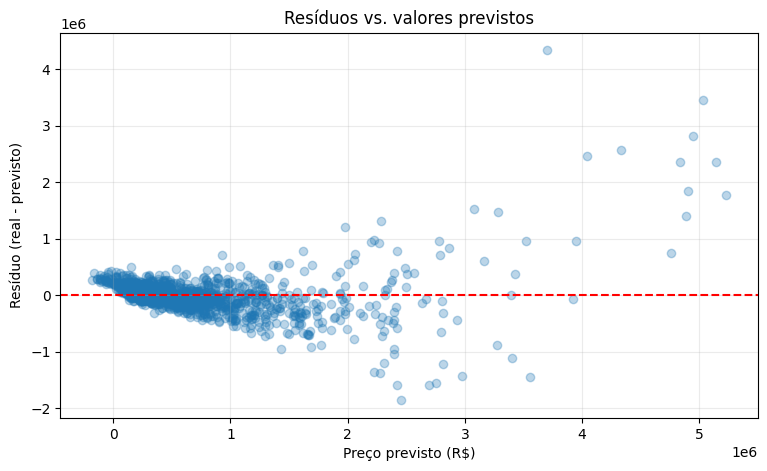

In [25]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(prev_polinomial, residuos, alpha=0.3)
ax.axhline(0, color="red", linestyle="--")
ax.set_title("Resíduos vs. valores previstos")
ax.set_xlabel("Preço previsto (R$)")
ax.set_ylabel("Resíduo (real - previsto)")
ax.grid(alpha=0.25)
plt.show()

**Interpretação (linearidade e homoscedasticidade).** Os resíduos se distribuem em torno
de zero, sem uma curva evidente — o que apoia a forma escolhida para o modelo.

No entanto, a dispersão **aumenta** conforme o preço previsto cresce, formando um "funil".
Isso é chamado de **heteroscedasticidade**: a variância dos erros não é constante. Na
prática, significa que o modelo é mais preciso em apartamentos de menor valor e menos
preciso nos de alto padrão.

**Alternativa de tratamento:** aplicar logaritmo na variável resposta costuma estabilizar a
variância em dados de preço.

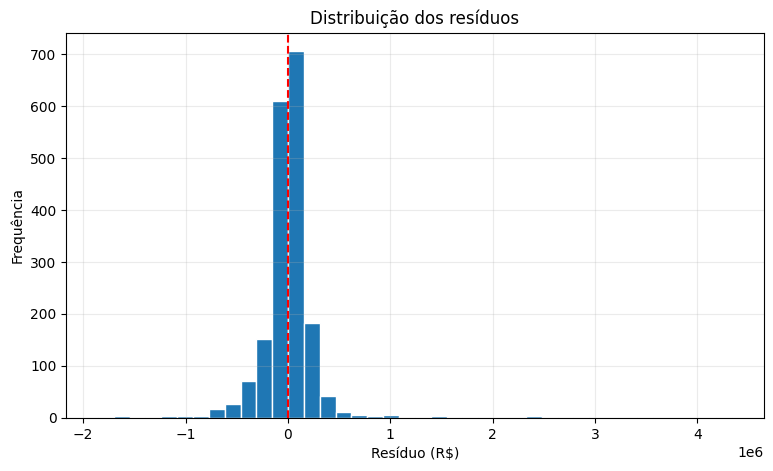

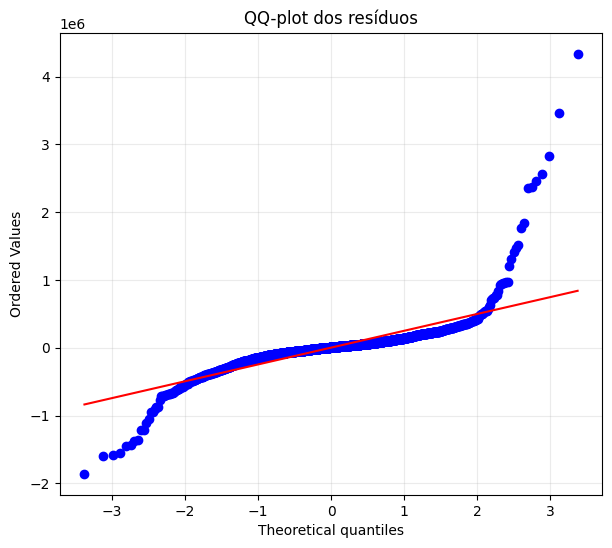

In [26]:
from scipy import stats

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(residuos, bins=40, edgecolor="white")
ax.axvline(0, color="red", linestyle="--")
ax.set_title("Distribuição dos resíduos")
ax.set_xlabel("Resíduo (R$)")
ax.set_ylabel("Frequência")
ax.grid(alpha=0.25)
plt.show()

fig, ax = plt.subplots(figsize=(7, 6))
stats.probplot(residuos, dist="norm", plot=ax)
ax.set_title("QQ-plot dos resíduos")
ax.grid(alpha=0.25)
plt.show()

**Interpretação (normalidade).** O histograma é aproximadamente simétrico e centrado em
zero. O **QQ-plot** compara os resíduos com o que seria esperado numa distribuição normal:
se os pontos seguem a reta, a normalidade é razoável.

No nosso caso, os pontos acompanham a reta na região central, mas se afastam bastante nas
extremidades — reflexo dos apartamentos de alto padrão, cujos erros são muito maiores. A
normalidade é, portanto, apenas **aproximada**.

In [27]:
# Analisando os maiores erros do modelo
comparacao = X_test.copy()
comparacao["preco_real"] = y_test.values
comparacao["preco_previsto"] = prev_polinomial.round(0)
comparacao["erro"] = np.abs(comparacao["preco_real"] - comparacao["preco_previsto"])

comparacao.nlargest(5, "erro")[["area_m2", "quartos", "vagas", "distrito",
                                 "preco_real", "preco_previsto", "erro"]]

,area_m2,quartos,vagas,distrito,preco_real,preco_previsto,erro
106,278,4,4,Vila Olimpia,8039200,3702664.0,4336536.0
2004,420,4,4,Jardim Paulista,8500000,5035607.0,3464393.0
1084,279,4,4,Iguatemi,7765616,4943227.0,2822389.0
3455,321,3,5,Itaim Bibi,6900000,4336032.0,2563968.0
3648,319,3,4,Alto de Pinheiros,6500000,4043582.0,2456418.0


**Interpretação.** Os maiores erros ocorrem em apartamentos de altíssimo valor,
em distritos nobres. São imóveis em que características não medidas pela base
— acabamento de luxo, vista, andar, área de lazer — pesam muito no preço.

Isso explica por que o **RMSE (R\$ 306.156) é bem maior que o MAE (R\$ 155.457)**:
como o RMSE eleva os erros ao quadrado, esses poucos erros muito grandes
elevam bastante a métrica. Na prática: o modelo acerta razoavelmente na
maioria dos imóveis, mas erra feio em alguns poucos de alto padrão.

In [28]:
# Colinearidade: verificamos a correlação entre as variáveis explicativas
df[num].corr().round(2)

,area_m2,quartos,banheiros,vagas
area_m2,1.00,0.66,0.68,0.72
quartos,0.66,1.00,0.55,0.59
banheiros,0.68,0.55,1.00,0.68
vagas,0.72,0.59,0.68,1.00


**Interpretação (colinearidade).** A **colinearidade** ocorre quando duas variáveis
explicativas medem quase a mesma coisa, o que torna os coeficientes instáveis e difíceis de
interpretar.

As correlações entre nossas variáveis explicativas são de moderadas a altas — a maior é
entre **área e vagas** (0,72), seguida de **área e banheiros** (0,68). Isso é esperado (apartamentos maiores costumam ter mais
banheiros) e ajuda a explicar o coeficiente negativo dos quartos observado anteriormente.
Como nenhuma correlação chega a valores extremos (próximos de 1), o modelo continua útil
para **previsão**, embora os coeficientes individuais devam ser interpretados com cautela.

**Alternativa de tratamento:** caso a colinearidade fosse mais grave, poderíamos usar
regularização (Ridge ou Lasso) ou reduzir o número de variáveis semelhantes.

**Independência dos erros.** Cada linha é um apartamento diferente (não é uma série
temporal), então a suposição de independência entre as observações é plausível.

## 9. Resultados e conclusão

**Quais variáveis mais explicam o preço?** A **área** é a mais forte (correlação de 0,82),
seguida pelas **vagas de garagem** (0,70) e pelos **banheiros** (0,64). O **distrito** também
tem peso enorme: entre os distritos com mais imóveis, a mediana vai de cerca de R\$ 324 mil
(Brás) a R\$ 1,28 milhão (Brooklin).

**As hipóteses iniciais foram confirmadas?**

- **H1** (área ↑ preço): **confirmada** — é a variável mais associada ao preço.
- **H2** (distrito influencia): **confirmada** — diferença de mais de 10 vezes entre distritos.
- **H3** (vagas ↑ preço): **confirmada** — cada vaga soma cerca de R\$ 237 mil.
- **H4** (relação não linear): **confirmada** — o modelo polinomial reduziu o erro no
  conjunto de teste (RMSE cerca de 4,5% menor).

**Qual o erro típico em dados não usados no treino?** O modelo erra, em média,
**R\$ 155.457 (MAE)**, com RMSE de R\$ 306.156 e **R² de 0,827** — ou seja, explica cerca de
83% da variação dos preços.

**Em quais situações o modelo é útil?** Para estimar a faixa de preço de apartamentos em
São Paulo com características semelhantes às da base, ajudando a avaliar se um anúncio está
fora do padrão do mercado.

**Em quais situações NÃO deve ser usado?** Para imóveis fora do perfil estudado (casas,
imóveis comerciais, terrenos), para outras cidades, ou para valores fora das faixas
observadas. Também não serve para afirmar **causalidade**: mostramos associação, não causa
e efeito.

**Quais limitações afetam as conclusões?**

- Os dados vêm de **anúncios**, refletindo o preço **pedido**, não necessariamente o preço
  de venda efetivo.
- São de **abril de 2019**, e o mercado imobiliário mudou desde então.
- A base não inclui informações importantes como andar, idade do prédio, estado de
  conservação, área de lazer e vista.
- O modelo é bem menos preciso para imóveis de alto padrão.
- Alguns distritos têm poucos imóveis, tornando suas estimativas instáveis.
- O diagnóstico indicou **heteroscedasticidade** (a dispersão dos erros cresce com o preço).
- **O efeito do distrito é aditivo, e não multiplicativo.** Esta é a limitação mais
  relevante que identificamos. Como o distrito entra no modelo somando um valor fixo em
  reais, a diferença entre dois bairros é sempre a mesma quantia, independentemente do
  tamanho do imóvel. Comparando Brás e Brooklin, por exemplo, a diferença prevista é de
  cerca de R\$ 205 mil nos dois casos: isso representa 44% num apartamento de 70 m², mas
  apenas 3,2% num de 620 m². No mercado real a localização **multiplica** o preço — o preço
  mediano por m² do Brooklin (R\$ 10.618) é 75% maior que o do Brás (R\$ 6.070) em qualquer
  tamanho. Por isso o modelo é mais confiável em imóveis de porte médio, dentro da faixa
  típica de cada distrito, e vai perdendo sentido conforme se afasta dela.

**O que faríamos diferente?** Aplicar **logaritmo na variável resposta** resolveria os dois
últimos pontos de uma vez: estabilizaria a variância dos erros e faria os coeficientes dos
distritos multiplicarem o preço em vez de somarem um valor fixo. Essa transformação está
fora do escopo desta atividade, mas é o caminho natural para uma versão futura do modelo.

**Que nova variável ou coleta melhoraria o modelo?** Incluir o **andar**, a **idade do
prédio**, o **estado de conservação** e a presença de **área de lazer**; e utilizar dados de
vendas efetivamente concretizadas, em vez de anúncios.

In [29]:
def montar_imovel(area_m2, quartos, banheiros, vagas, distrito, colunas_modelo):
    """Monta um imóvel novo com o MESMO preparo usado no treino."""
    linha = pd.DataFrame([{
        "area_m2": area_m2,
        "quartos": quartos,
        "banheiros": banheiros,
        "vagas": vagas,
        "distrito": distrito,
    }])
    linha = pd.get_dummies(linha, columns=["distrito"])
    linha["area_quadrado"] = linha["area_m2"] ** 2
    return linha.reindex(columns=colunas_modelo, fill_value=0)


colunas_modelo = X_train_p.columns

# Exemplo 1: apartamento médio em bairro de classe média
exemplo1 = montar_imovel(70, 2, 2, 1, "Santana", colunas_modelo)
# Exemplo 2: apartamento maior em bairro nobre
exemplo2 = montar_imovel(150, 3, 4, 3, "Moema", colunas_modelo)

print("Exemplo 1 — 70 m², 2 quartos, 2 banheiros, 1 vaga, Santana")
print("  Preço previsto: R$", round(float(modelo_polinomial.predict(exemplo1)[0])))
print()
print("Exemplo 2 — 150 m², 3 quartos, 4 banheiros, 3 vagas, Moema")
print("  Preço previsto: R$", round(float(modelo_polinomial.predict(exemplo2)[0])))

Exemplo 1 — 70 m², 2 quartos, 2 banheiros, 1 vaga, Santana
  Preço previsto: R$ 204955

Exemplo 2 — 150 m², 3 quartos, 4 banheiros, 3 vagas, Moema
  Preço previsto: R$ 2061938


**Interpretação das previsões.** O apartamento maior, com mais banheiros e vagas, em um
distrito mais valorizado, tem preço previsto muito superior ao do apartamento médio — o que é
coerente com todas as relações que encontramos.

**Risco de extrapolação.** Os dois exemplos estão dentro das faixas observadas na base (área
de 30 a 620 m², de 1 a 6 quartos). Fazer previsões fora dessas faixas — por exemplo, um
apartamento de 1.000 m² — seria **extrapolação**: o modelo nunca viu casos assim e a previsão
não seria confiável.

É importante notar que essas faixas **variam muito entre distritos**. O maior apartamento do
Brás na base tem 196 m² e 2 vagas, enquanto o Brooklin chega a 315 m² e 4 vagas. Simular um
imóvel de 400 m² no Brás está dentro da faixa **global**, mas descreve uma combinação que não
existe naquele bairro. Por isso a aplicação em Streamlit verifica as faixas do **distrito
selecionado**, e não apenas as faixas gerais da base.

## 10. Salvando o modelo e a base tratada

Salvamos o modelo treinado e a base limpa para que a aplicação em Streamlit utilize
exatamente o mesmo modelo desenvolvido aqui.

In [30]:
import joblib

# Guardamos as faixas observadas para o aviso de extrapolação na aplicação.
# Além das faixas gerais, guardamos as faixas de CADA distrito, porque elas
# variam bastante de um bairro para outro.
faixas = {c: (float(df[c].min()), float(df[c].max())) for c in num}
faixas_distrito = {
    distrito: {c: (float(grupo[c].min()), float(grupo[c].max())) for c in num}
    for distrito, grupo in df.groupby("distrito")
}

pacote = {
    "modelo": modelo_polinomial,
    "colunas": list(colunas_modelo),
    "distritos": sorted(df["distrito"].unique().tolist()),
    "faixas": faixas,
    "faixas_distrito": faixas_distrito,
    "metricas": {
        "MAE": round(mean_absolute_error(y_test, prev_polinomial)),
        "RMSE": round(float(np.sqrt(mean_squared_error(y_test, prev_polinomial)))),
        "R2": round(r2_score(y_test, prev_polinomial), 3),
    },
}

joblib.dump(pacote, "modelo_imoveis_sp.pkl")
df.to_csv("base_tratada.csv", index=False)

print("Arquivos salvos com sucesso.")
print("Métricas do modelo final:", pacote["metricas"])
print("Faixas do Brás:", faixas_distrito["Brás"])

Arquivos salvos com sucesso.
Métricas do modelo final: {'MAE': 155457, 'RMSE': 306156, 'R2': 0.827}
Faixas do Brás: {'area_m2': (30.0, 196.0), 'quartos': (1.0, 4.0), 'banheiros': (1.0, 3.0), 'vagas': (0.0, 2.0)}


Para baixar os arquivos do Google Colab, execute a célula abaixo.

In [31]:
# Download dos arquivos (apenas no Google Colab)
#try:
#   from google.colab import files
#    files.download("modelo_imoveis_sp.pkl")
#    files.download("base_tratada.csv")
#except ImportError:
#    print("Fora do Colab: os arquivos foram salvos na pasta do notebook.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>